In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
df=pd.read_csv('water_potability.csv')
df.head(10)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [7]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [9]:
df.shape

(3276, 10)

In [12]:
df['Potability'].value_counts()

,count
Potability,
0,1998
1,1278


In [13]:
# Bo'shliqlarni to'ldirish
df['ph'] = df['ph'].fillna(df['ph'].mean())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].mean())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean())

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


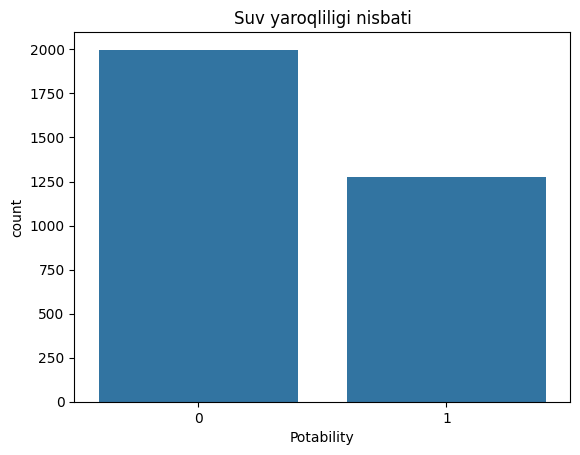

In [15]:
sns.countplot(x='Potability', data=df)
plt.title('Suv yaroqliligi nisbati')
plt.show()

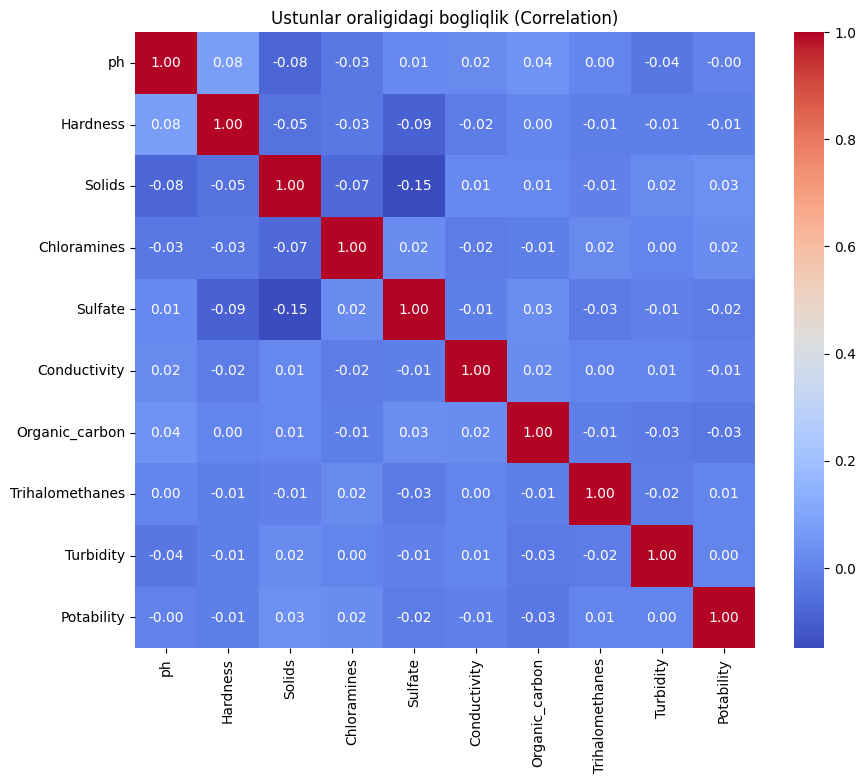

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ustunlar oraligidagi bogliqlik (Correlation)')
plt.show()

1. Korrelyatsiyaning yo'qligi (Weak Correlation)
E'tibor bergan bo'lsangiz, Potability (eng pastki qatorda) bilan boshqa barcha ustunlar orasidagi ko'rsatkichlar 0 ga juda yaqin (masalan: ph bilan -0.00, Sulfate bilan -0.02).

Bu nima degani? Suvning ichishga yaroqliligini bitta ko'rsatkichga qarab (faqat pH yoki faqat xlorga qarab) aniqlab bo'lmaydi.

Xulosa: Ma'lumotlar o'rtasida chiziqli bog'liqlik yo'q. Bu shuni isbotlaydiki, bizga murakkabroq algoritmlar (Random Forest, Gradient Boosting) kerak.

2. Ustunlarning mustaqilligi
Barcha ko'k kataklar ko'rsatmoqdaki, kimyoviy elementlar bir-biriga deyarli ta'sir qilmaydi (ko'rsatkichlar 0.1 dan past). Bu yaxshi, chunki ML modelimizga bir-birini takrorlovchi "ortiqcha" ma'lumotlar (multicollinearity) xalaqit bermaydi.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
# 'Potability' ustunini y ga olamiz, qolgan hamma ustunlarni X ga
X = df.drop('Potability', axis=1)
y = df['Potability']

print("X xususiyatlari shakli:", X.shape)
print("y javoblari shakli:", y.shape)

X xususiyatlari shakli: (3276, 9)
y javoblari shakli: (3276,)


In [20]:
# Ma'lumotni 80% o'qitish va 20% test qilish uchun bo'lamiz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"O'qitish uchun: {len(X_train)} ta namuna")
print(f"Test qilish uchun: {len(X_test)} ta namuna")

O'qitish uchun: 2620 ta namuna
Test qilish uchun: 656 ta namuna


In [21]:
# 1. Modelni yaratish
# n_estimators=100 - bu 100 ta qaror daraxti qurishni anglatadi
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Modelni o'qitish
# Bu bosqichda model X_train va y_train o'rtasidagi bog'liqlikni o'rganadi
rf_model.fit(X_train, y_train)

print("Model muvaffaqiyatli o'qitildi!")

Model muvaffaqiyatli o'qitildi!


In [22]:
# 1. Test ma'lumotlari uchun bashorat qilish
y_pred = rf_model.predict(X_test)

# 2. Aniqlik darajasini tekshirish
accuracy = accuracy_score(y_test, y_pred)
print(f"Modelning umumiy aniqligi (Accuracy): {accuracy * 100:.2f}%")

# 3. Batafsil hisobot
print("\nKlassifikatsiya hisoboti:")
print(classification_report(y_test, y_pred))

Modelning umumiy aniqligi (Accuracy): 67.84%

Klassifikatsiya hisoboti:
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       412
           1       0.61      0.38      0.47       244

    accuracy                           0.68       656
   macro avg       0.65      0.62      0.62       656
weighted avg       0.67      0.68      0.66       656



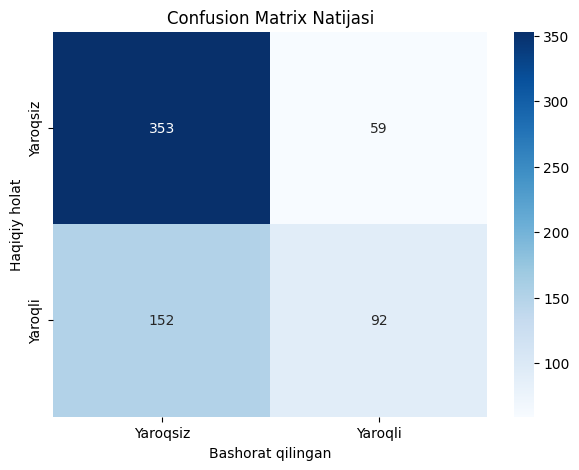

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Yaroqsiz', 'Yaroqli'],
            yticklabels=['Yaroqsiz', 'Yaroqli'])
plt.xlabel('Bashorat qilingan')
plt.ylabel('Haqiqiy holat')
plt.title('Confusion Matrix Natijasi')
plt.show()

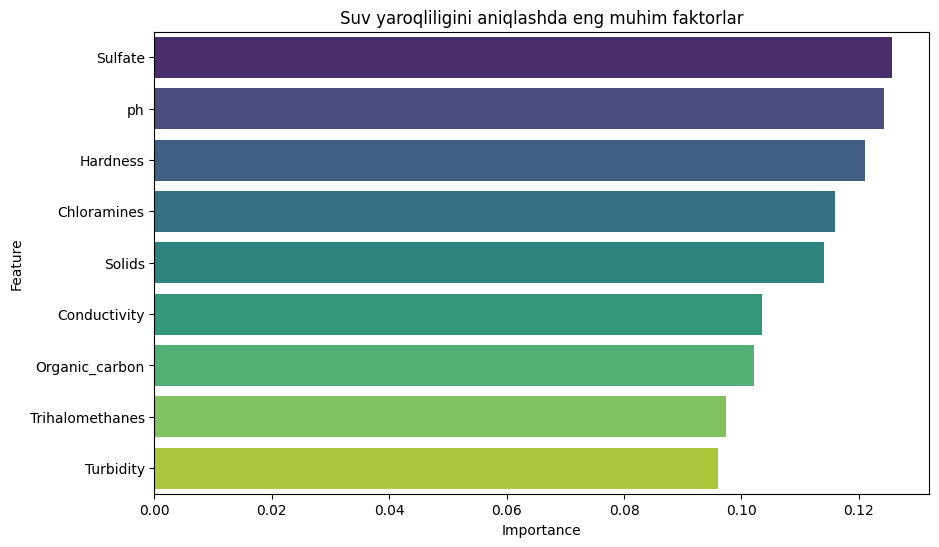

In [24]:
# Qaysi xususiyat model uchun eng muhim bo'lganini ko'ramiz
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Suv yaroqliligini aniqlashda eng muhim faktorlar')
plt.show()